# Introducción al Tratamiento de Series Temporales
En este notebook aprenderás los conceptos fundamentales de las series temporales, cómo se estructuran, cómo se visualizan y cómo se procesan. Incluiremos teoría explicada con claridad para quienes nunca han trabajado con este tipo de datos, junto con ejemplos prácticos en Python.

## ¿Qué es una serie temporal?
Una **serie temporal** es un conjunto de observaciones ordenadas en el tiempo. Cada dato tiene asociado un instante temporal. Algunos ejemplos comunes son:
* Temperatura diaria
* Ventas mensuales de una empresa
* Señales biométricas (ritmo cardíaco, acelerometría, etc.)
* Tráfico en una web por horas

Las series temporales suelen presentar patrones como:
* **Tendencia**: evolución creciente o decreciente a largo plazo.
* **Estacionalidad**: fluctuaciones periódicas.
* **Ciclo**: movimientos amplios relacionados con factores externos.
* **Ruido**: variabilidad aleatoria sin patrón visible.

## Cargar y visualizar una serie temporal en Python
Para trabajar con series temporales usaremos `pandas` y `matplotlib`.

### Detección de patrones en series temporales

Hay cuatro tipos de patrones que normalmente debemos tener en cuenta al analizar datos de series temporales. Estos incluyen tendencias, variaciones estacionales, variaciones cíclicas y variaciones irregulares. Los gráficos de líneas son muy útiles para analizar estos patrones. Con los gráficos de líneas, podemos detectar fácilmente estos patrones dentro de nuestro conjunto de datos.    

- Al analizar nuestros datos en busca de tendencias, tratamos de detectar un aumento o una disminución a largo plazo en los valores de la serie temporal.    
- Al analizar nuestros datos en busca de variaciones estacionales, tratamos de identificar patrones periódicos que están influenciados por el calendario (trimestre, mes, día de la semana, etc.).    
- Al analizar nuestros datos en busca de variaciones cíclicas, intentamos detectar secciones en las que los puntos de datos suben y bajan con magnitudes variables y durante períodos más largos que no son fijos; por ejemplo, la duración de un ciclo es de al menos dos años, y cada ciclo puede ocurrir en un rango de años (como cada dos o cuatro años) y no en un período fijo (como cada dos años).   

Detectaremos patrones en los datos de series temporales utilizando el gráfico de líneas y el diagrama de caja. Para ello, utilizaremos el método plot en matplotlib y el método boxplot en seaborn.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
air_traffic_data = pd.read_csv("/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/DATASETS/SF_Air_Traffic_Passenger_Statistics_Transformed.csv")
air_traffic_data.head()

,Date,Total Passenger Count
0,200601,2448889
1,200602,2223024
2,200603,2708778
3,200604,2773293
4,200605,2829000


In [5]:
air_traffic_data.shape

(132, 2)

In [6]:
air_traffic_data.dtypes

Date                     int64
Total Passenger Count    int64
dtype: object

Convertimos la columna "Date" a formato *datetime*:

In [7]:
air_traffic_data['Date']= pd.to_datetime(air_traffic_data['Date'], format = "%Y%m")
air_traffic_data.dtypes

Date                     datetime64[ns]
Total Passenger Count             int64
dtype: object

Fijamos la fecha como índice del dataframe:

In [8]:
air_traffic_data.set_index('Date',inplace = True)
air_traffic_data.shape

(132, 1)

Mostramos una gráfica con la serie temporal:

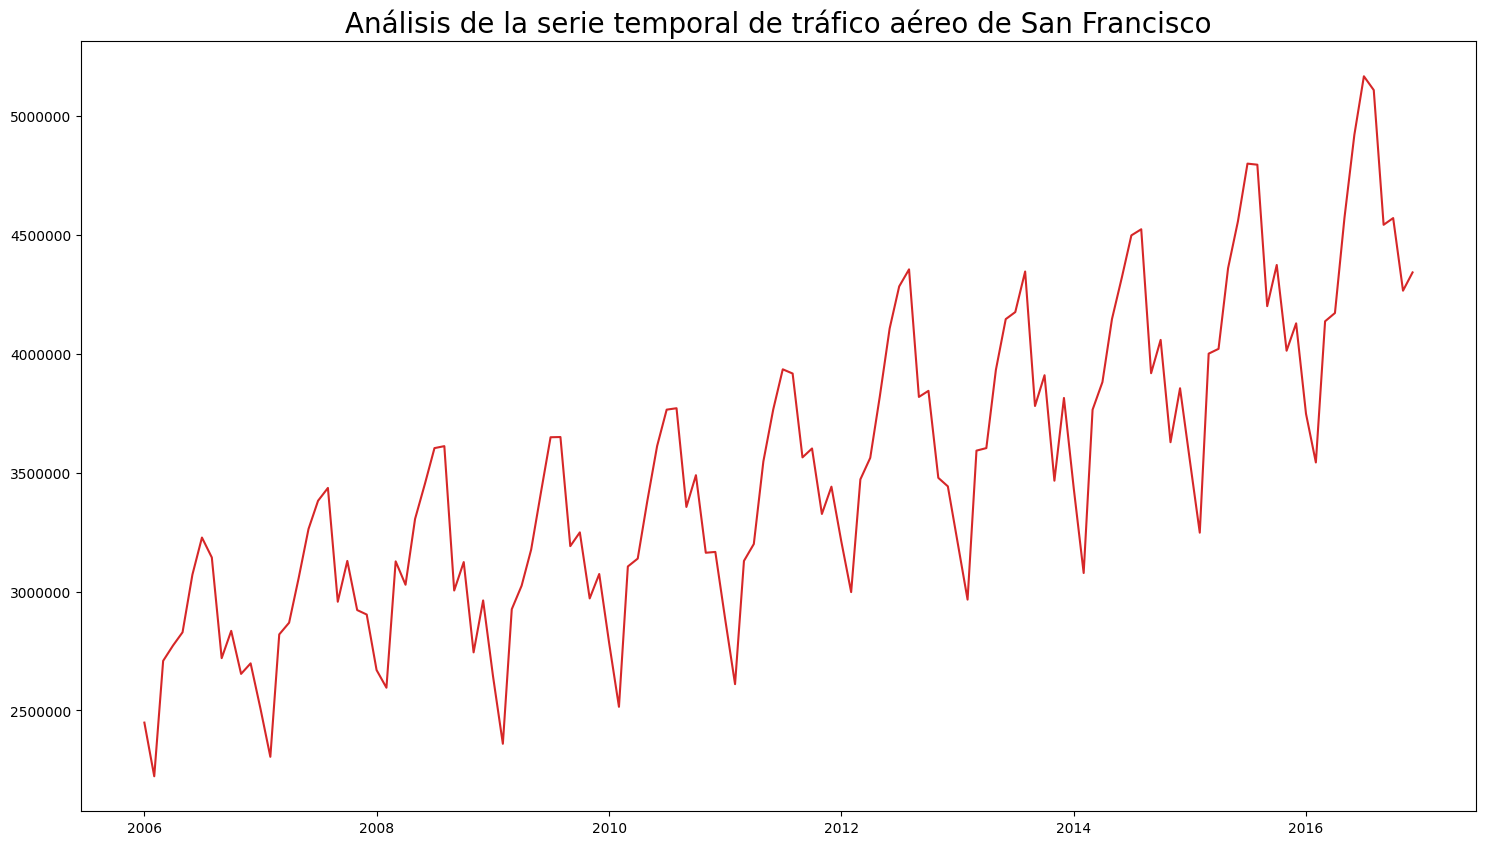

In [10]:
plt.figure(figsize= (18,10))
plt.plot(air_traffic_data.index, air_traffic_data['Total Passenger Count'], color='tab:red')
plt.title("Análisis de la serie temporal de tráfico aéreo de San Francisco",fontsize = 20)
plt.ticklabel_format(style='plain', axis='y')

Ahora vamos a usar la gráfica tipo Caja y Bigotes (boxplot) de seaborn para realizar una nueva visualización pero, en este caso, solo de un subconjunto de datos correspondiente a un rango de fechas determinado.   

Para el valor correspondiente al segundo parámetro del dataset se ha aplicado el método de Pandas ```PeriodIndex``` que divide la fecha en cuartos por año.

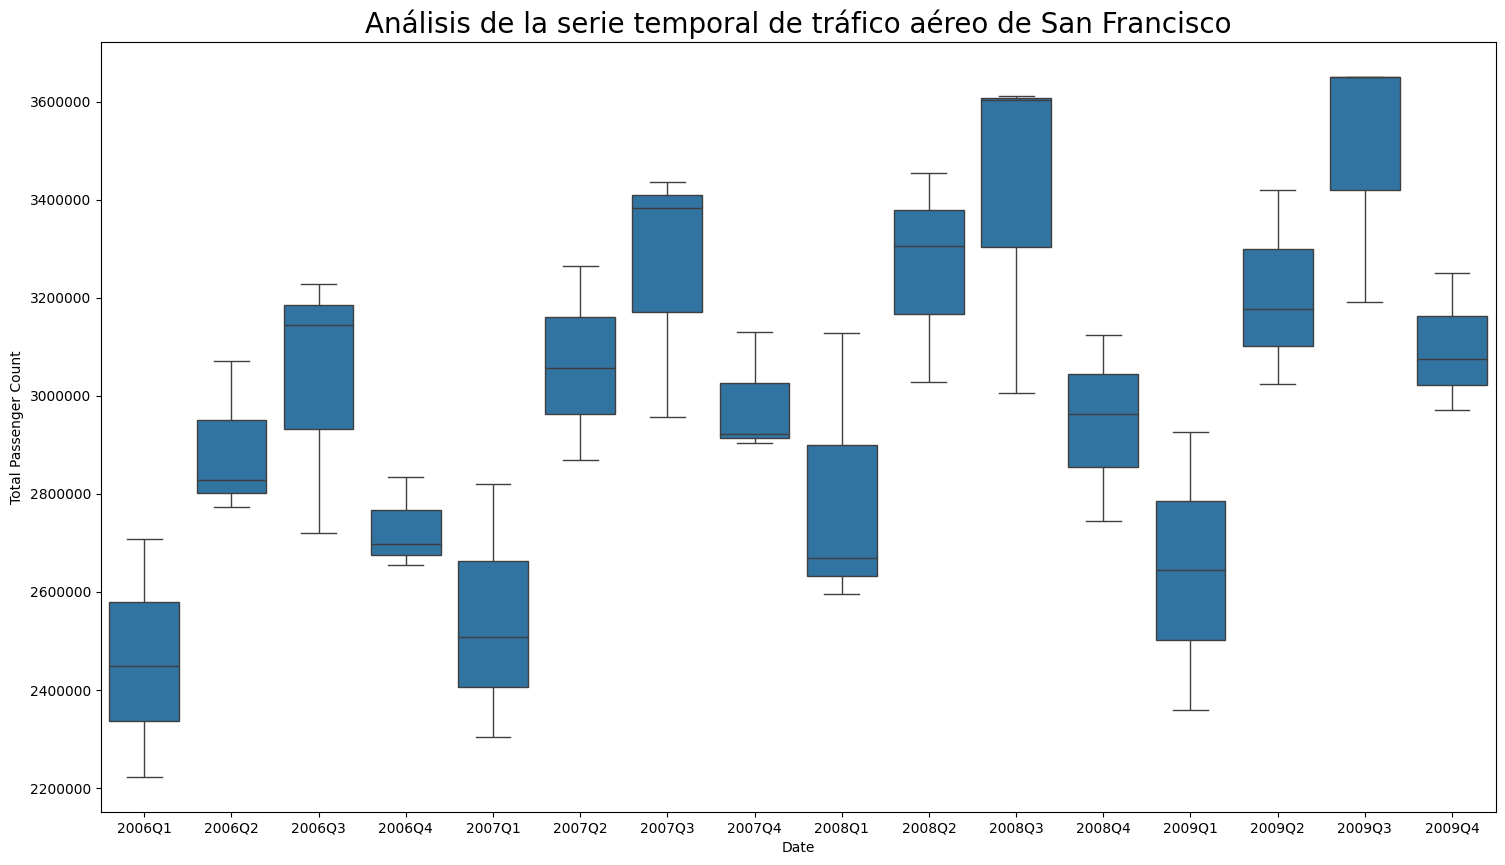

In [13]:
plt.figure(figsize= (18,10))
data_subset = air_traffic_data[air_traffic_data.index < '2010-01-01']
ax = sns.boxplot(data = data_subset , x= pd.PeriodIndex(data_subset.index, freq='Q'), y= data_subset['Total Passenger Count'])
ax.set_title("Análisis de la serie temporal de tráfico aéreo de San Francisco",fontsize = 20)
plt.ticklabel_format(style='plain', axis='y')

- En el gráfico de líneas, podemos observar una tendencia al alza, dado el aumento de los valores del número de pasajeros. También podemos observar la estacionalidad por las fluctuaciones anuales constantes que vemos cada año; observamos picos significativos alrededor de mediados de año. Probablemente se trate del verano. Los datos de la serie temporal no presentan fluctuaciones cíclicas.
- En el diagrama de caja, podemos observar fluctuaciones a lo largo de los trimestres del año. Los trimestres 2 (Q2) y 3 (Q3) parecen tener el mayor número de pasajeros a lo largo de los años.

## Realizando la descomposición de los datos de la serie temporal   

La descomposición es el proceso de dividir los datos de series temporales en componentes individuales para obtener una mejor comprensión de los patrones subyacentes. En general, la descomposición nos ayuda a comprender mejor los patrones subyacentes en nuestras series temporales.     

Los componentes se definen de la siguiente manera:   

- **Tendencia**: el aumento o la disminución a largo plazo de los valores de la serie temporal
- **Estacionalidad**: las variaciones de la serie temporal que están influenciadas por factores estacionales (por ejemplo, trimestre, mes, semana o día)
- **Residual**: los patrones que quedan después de tener en cuenta la tendencia y la estacionalidad. También se considera ruido (variación aleatoria en la serie temporal)   

Como se puede observar, las variaciones cíclicas cubiertas en recetas anteriores no aparecen como un componente en las series temporales descompuestas. Por lo general, se combinan con el componente de tendencia y se denominan tendencia.
Al descomponer nuestras series temporales, podemos considerarlas como una combinación aditiva o multiplicativa de los componentes de tendencia, estacionalidad y residual.    

La fórmula para cada modelo se muestra aquí:    

- Modelo Aditivo:   $ Y = T + S + R $    
- Modelo Multiplicativo:   $ Y = T * S * R $

Dónde Y es la serie, T es la tendencia, S es la estacionalidad y R es el ruido.     

El modelo aditivo es adecuado cuando la variación estacional es relativamente constante a lo largo del tiempo, mientras que el modelo multiplicativo es adecuado cuando la variación estacional aumenta con el tiempo.     
En el modelo multiplicativo, el tamaño/magnitud de las fluctuaciones no es constante, sino que aumenta con el tiempo.
Para explorar los modelos de descomposición aditiva y multiplicativa se usará ```seasonal_decompose``` de ```statsmodel```.   



Los modelos de descomposición multiplicativa se pueden representar de la siguiente manera:

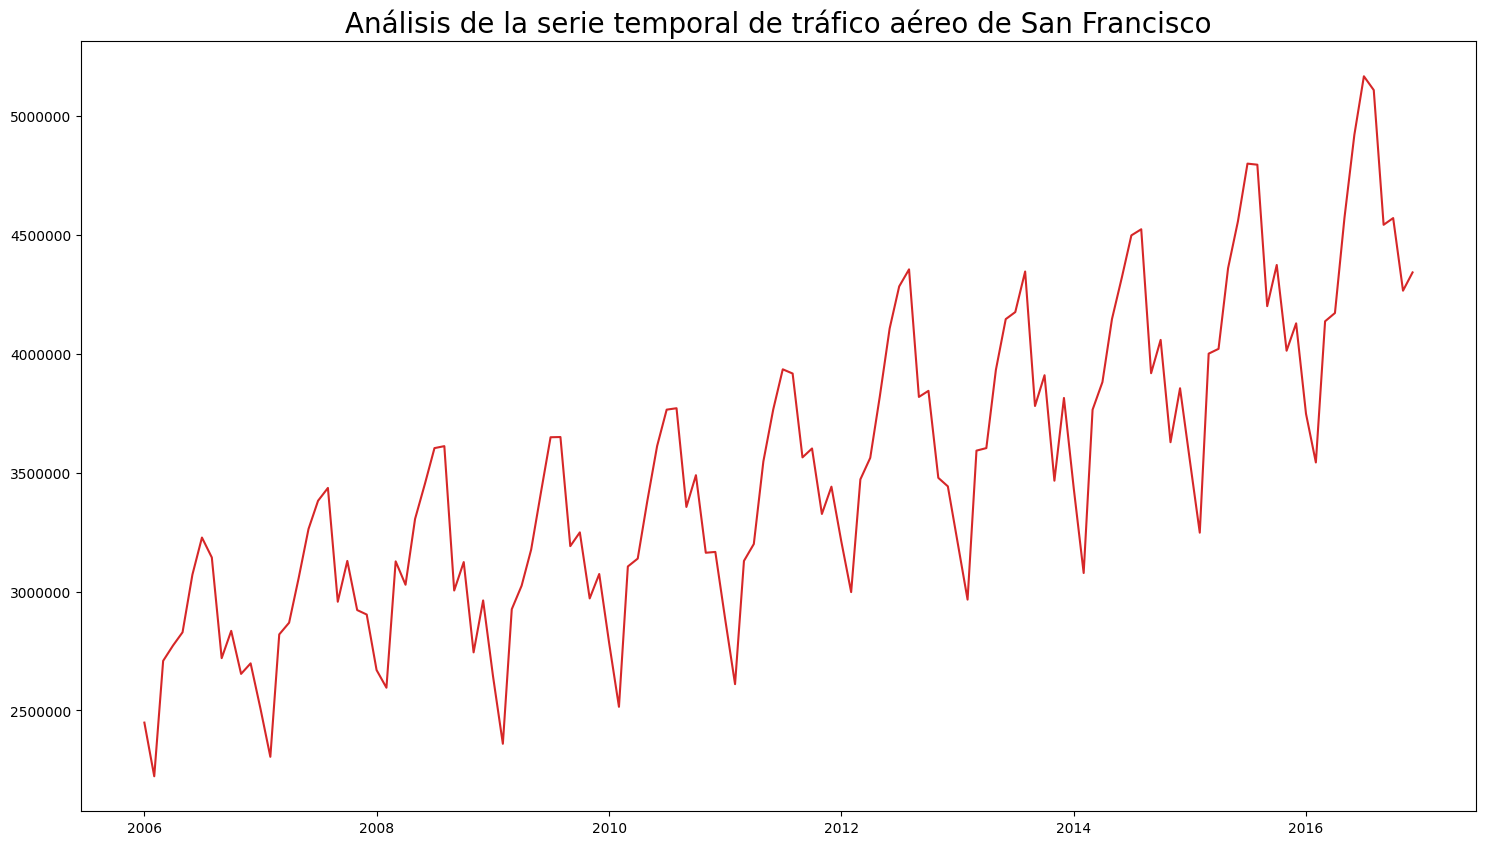

In [14]:
plt.figure(figsize= (18,10))
plt.plot(air_traffic_data.index, air_traffic_data['Total Passenger Count'], color='tab:red')
plt.title("Análisis de la serie temporal de tráfico aéreo de San Francisco",fontsize = 20)
plt.ticklabel_format(style='plain', axis='y')

Y para una descomposición aditiva tenemos:

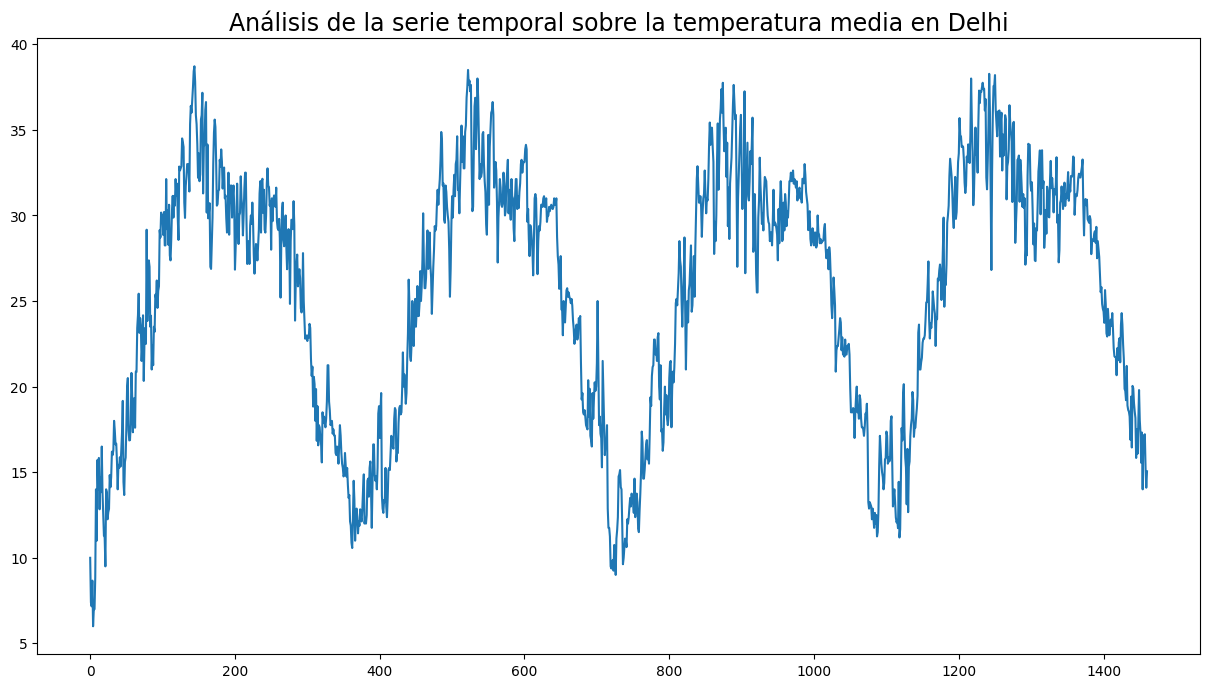

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

weather_data = pd.read_csv("/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/DATASETS/DailyDelhiClimate.csv")

plt.figure(figsize= (15,8))
plt.plot(weather_data.index, weather_data['meantemp'],
color='tab:blue')
plt.title("Análisis de la serie temporal sobre la temperatura media en Delhi",fontsize = 17)
plt.ticklabel_format(style='plain', axis='y')

A continuación, se realiza una descomposición de la serie temporal sobre tráfico aéreo usando un modelo multiplicativo:

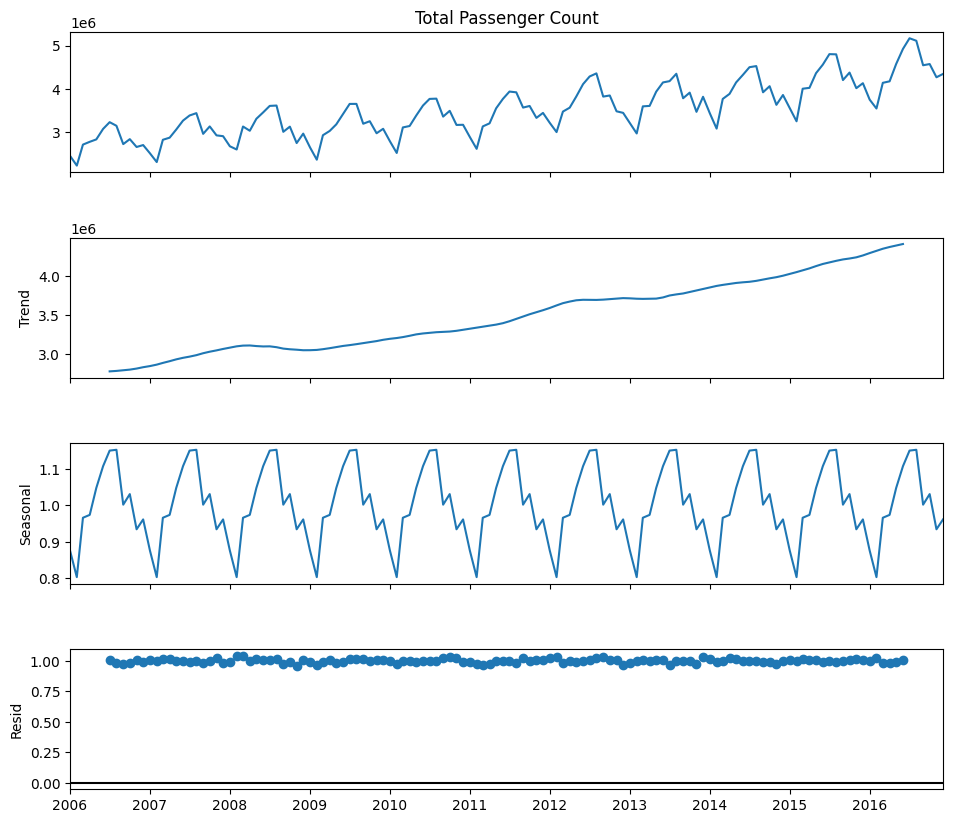

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_multi = seasonal_decompose(air_traffic_data['Total Passenger Count'], model='multiplicative', period = 12)
fig = decomposition_multi.plot()
fig.set_size_inches((10, 9))
plt.show()

Ahora se descompone la serie temporal sobre la temperatura de Delhi usando un modelo aditivo:

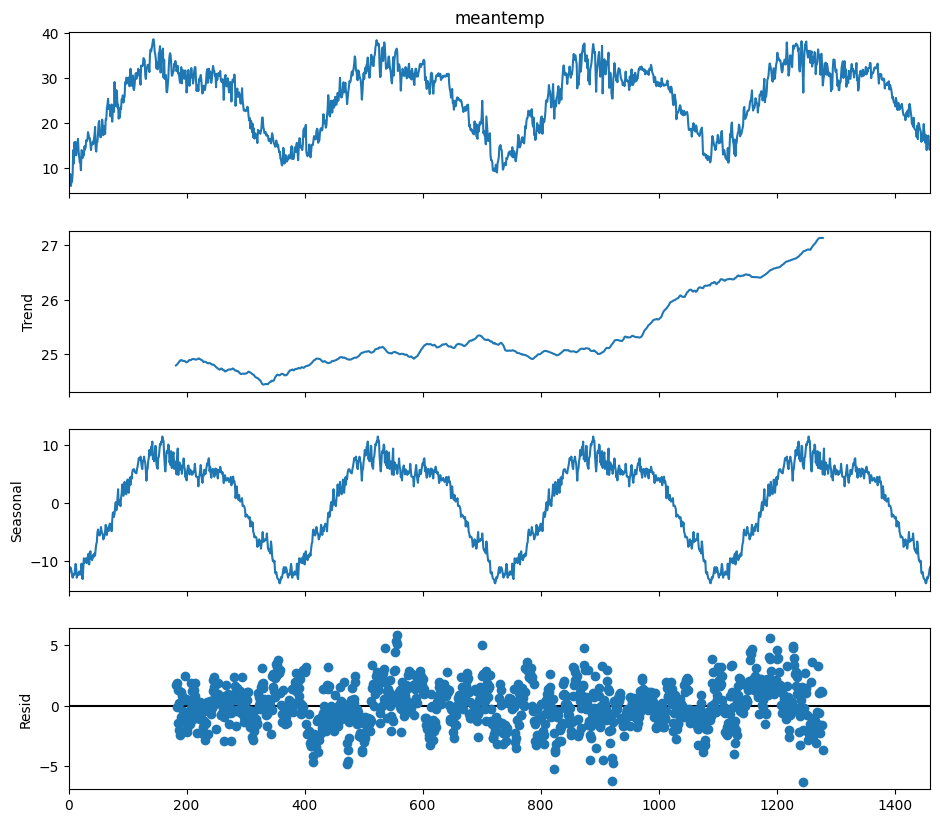

In [21]:
decomposition_add = seasonal_decompose(weather_data['meantemp'], model='additive',period = 365)
fig = decomposition_add.plot()
fig.set_size_inches((10, 9))
plt.show()

Utilizamos la clase ```seasonal_decompose``` en ```statsmodel``` para descomponer los datos meteorológicos.   

Se utiliza un modelo aditivo porque la variación estacional es constante a lo largo del tiempo. Una vez más, especificamos los datos como primer argumento, el tipo de modelo como segundo argumento y el período como tercero.    

Se utilizó un período de 365 porque suponemos que el patrón estacional se repite cada año y, dado que nuestros datos tienen una frecuencia diaria, hay 365 observaciones en un año.   

La descomposición da los siguientes componentes en su salida:   

- **Serie temporal original**: se trata de un gráfico de líneas que muestra la serie temporal original.
- **Tendencia**: muestra el aumento o la disminución a largo plazo de los valores de la serie temporal. En los datos de la serie temporal del tráfico aéreo, podemos observar una fuerte tendencia, que es el resultado de los grandes cambios en el número de pasajeros durante el periodo de 10 años (se debe tener en cuenta que el eje Y del gráfico de tendencias está en millones). Por otro lado, los datos de la serie temporal meteorológica muestran una tendencia débil durante el periodo de cuatro años, dados los pequeños cambios en la temperatura media durante este tiempo.
- **Estacional**: muestra las variaciones que están influenciadas por factores estacionales. Ambos datos de la serie temporal muestran patrones estacionales fuertes.
- **Residual**: muestra las fluctuaciones que quedan después de tener en cuenta la tendencia y la estacionalidad. Los datos de la serie temporal del tráfico aéreo muestran valores residuales muy mínimos, lo que significa que la tendencia y la estacionalidad explican la mayor parte de las fluctuaciones en los datos. Sin embargo, los datos de la serie temporal meteorológica tienen valores residuales más altos, lo que significa que la tendencia y la estacionalidad no explican una proporción significativa de las fluctuaciones en los datos.

## Suavizado    

El suavizado se suele realizar como parte del análisis de series temporales para revelar mejor los patrones y las tendencias. Las técnicas de suavizado pueden ayudar a eliminar el ruido de nuestro conjunto de datos de series temporales, lo que reduce el impacto de las fluctuaciones a corto plazo y revela mejor los patrones subyacentes.   

La **media móvil** es una técnica de suavizado muy utilizada que ayuda a identificar tendencias y patrones en datos de series temporales. Funciona calculando *la media de un conjunto de puntos de datos adyacentes* en la serie temporal.   

El número de puntos adyacentes viene determinado por *el tamaño de la ventana*. La ventana se refiere al **número de períodos para los que queremos calcular una media**. Esta ventana se suele elegir en función de la frecuencia de los datos y la naturaleza de los patrones que intentamos identificar.    

Por ejemplo, si tenemos datos diarios sobre el precio de las acciones, podemos decidir calcular el precio medio de los últimos 10 días, incluido el día de hoy. En este caso, 10 días es el tamaño de la ventana. Para lograr la parte «móvil», tendremos que deslizar la ventana a lo largo de la serie temporal para calcular los valores medios. En términos sencillos, esto significa que el 20 de enero, la ventana de 10 días abarcará del 11 al 20 de enero, mientras que el 21 de enero, la ventana abarcará del 12 al 21 de enero.   

Normalmente, podemos visualizar la media móvil frente a la serie temporal original, con el fin de identificar cualquier tendencia o patrón que esté presente. Las ventanas cortas se utilizan a menudo para capturar fluctuaciones a corto plazo o cambios rápidos en los datos, mientras que las ventanas largas se utilizan para capturar tendencias a más largo plazo y suavizar
las fluctuaciones a corto plazo.   

En general, el suavizado también se puede utilizar para identificar valores atípicos o cambios repentinos en la serie temporal. Exploraremos la técnica de suavizado de la media móvil en Python. Utilizaremos los métodos ```rolling``` y ```mean``` en ```pandas```.

A continuación se verá como calcular la **media móvil** usando ```pandas```:

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
stock_data = pd.read_csv("/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/DATASETS/MTNOY.csv")
stock_data = stock_data[['Date','Close']]

In [24]:
stock_data.head()

,Date,Close
0,2010-02-01,14.70
1,2010-02-02,14.79
2,2010-02-03,14.60
3,2010-02-04,14.10
4,2010-02-05,14.28


In [25]:
stock_data.shape

(1490, 2)

Convertimos la columna "Date" a formato fecha

In [26]:
stock_data['Date']= pd.to_datetime(stock_data['Date'], format ="%Y-%m-%d")
stock_data.dtypes

Date     datetime64[ns]
Close           float64
dtype: object

Establecemos la columna "Date" como el índice del dataframe:

In [27]:
stock_data.set_index('Date',inplace = True)
stock_data.shape

(1490, 1)

Graficamos:

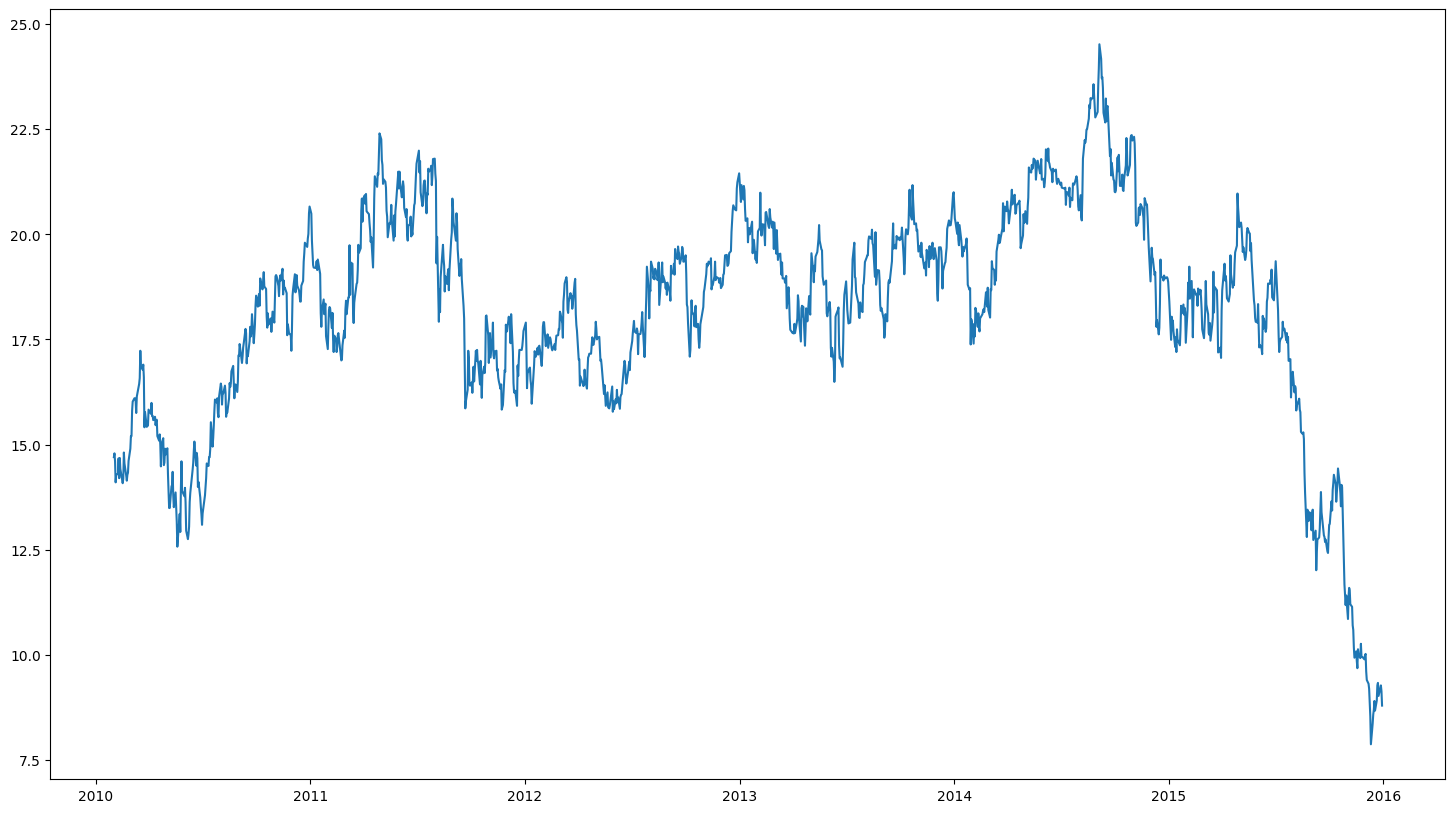

In [28]:
plt.figure(figsize= (18,10))
plt.plot(stock_data.index, stock_data['Close'],color='tab:blue')

Realizamos la media móvil usando ```rolling``` y ```mean``` de ```pandas```:

In [29]:
moving_data = stock_data.rolling(window=4)
moving_average_data = moving_data.mean()
moving_average_data.head()

,Close
Date,
2010-02-01,NaN
2010-02-02,NaN
2010-02-03,NaN
2010-02-04,14.5475
2010-02-05,14.4425


Graficamos superponiendo la media móvil sobre la serie original usando ```plot``` de ```matplotlib```:

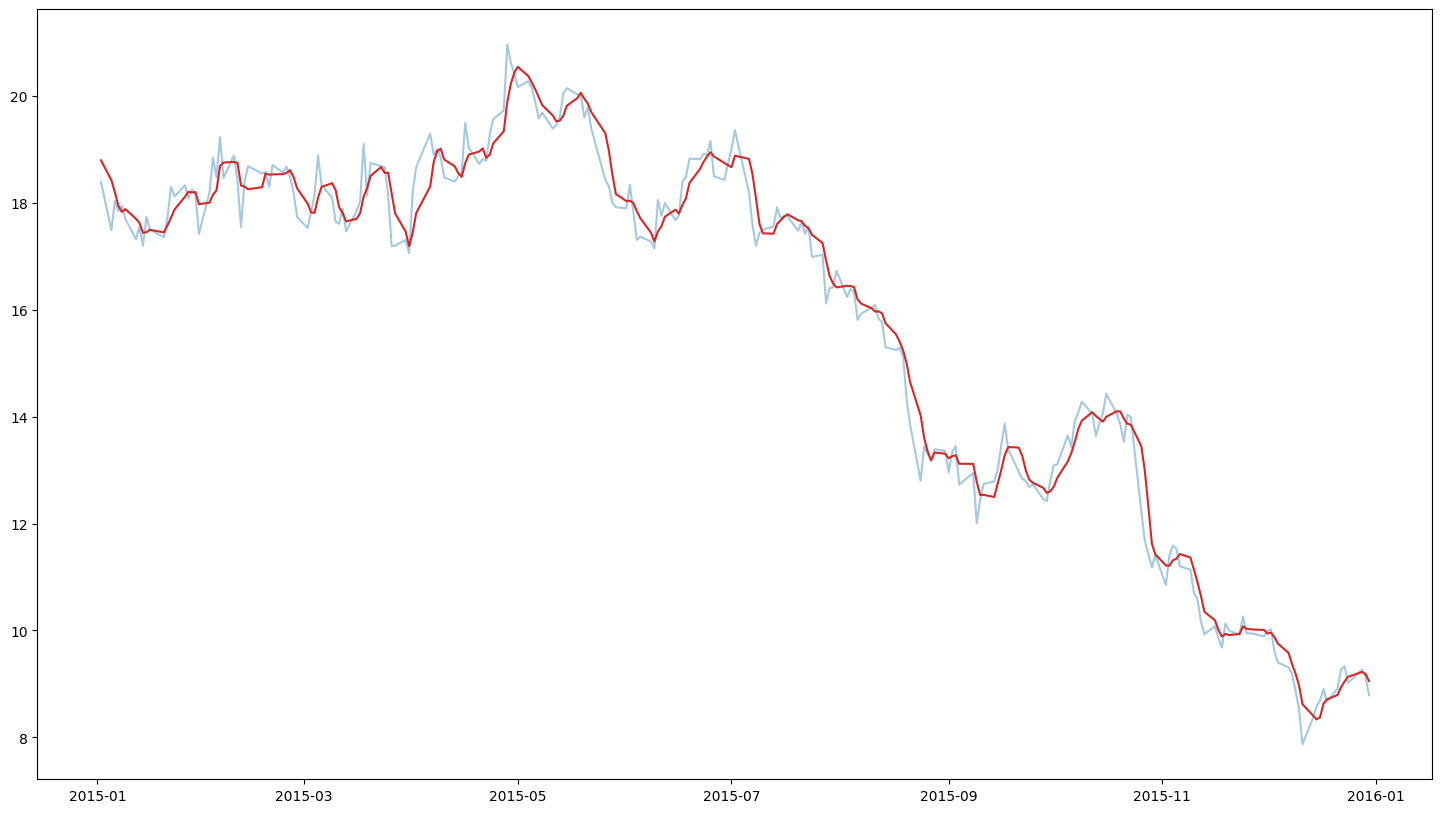

In [30]:
plt.figure(figsize= (18,10))
stock_data_subset = stock_data[stock_data.index>= '2015-01-01']
moving_average_data_subset = moving_average_data[moving_average_data.index>= '2015-01-01']
plt.plot(stock_data_subset.index, stock_data_subset['Close'],color='tab:blue',alpha = 0.4)
plt.plot(moving_average_data_subset.index,moving_average_data_subset['Close'],color='tab:red')

Calculamos el ruido y graficamos dicho ruido en un histograma:

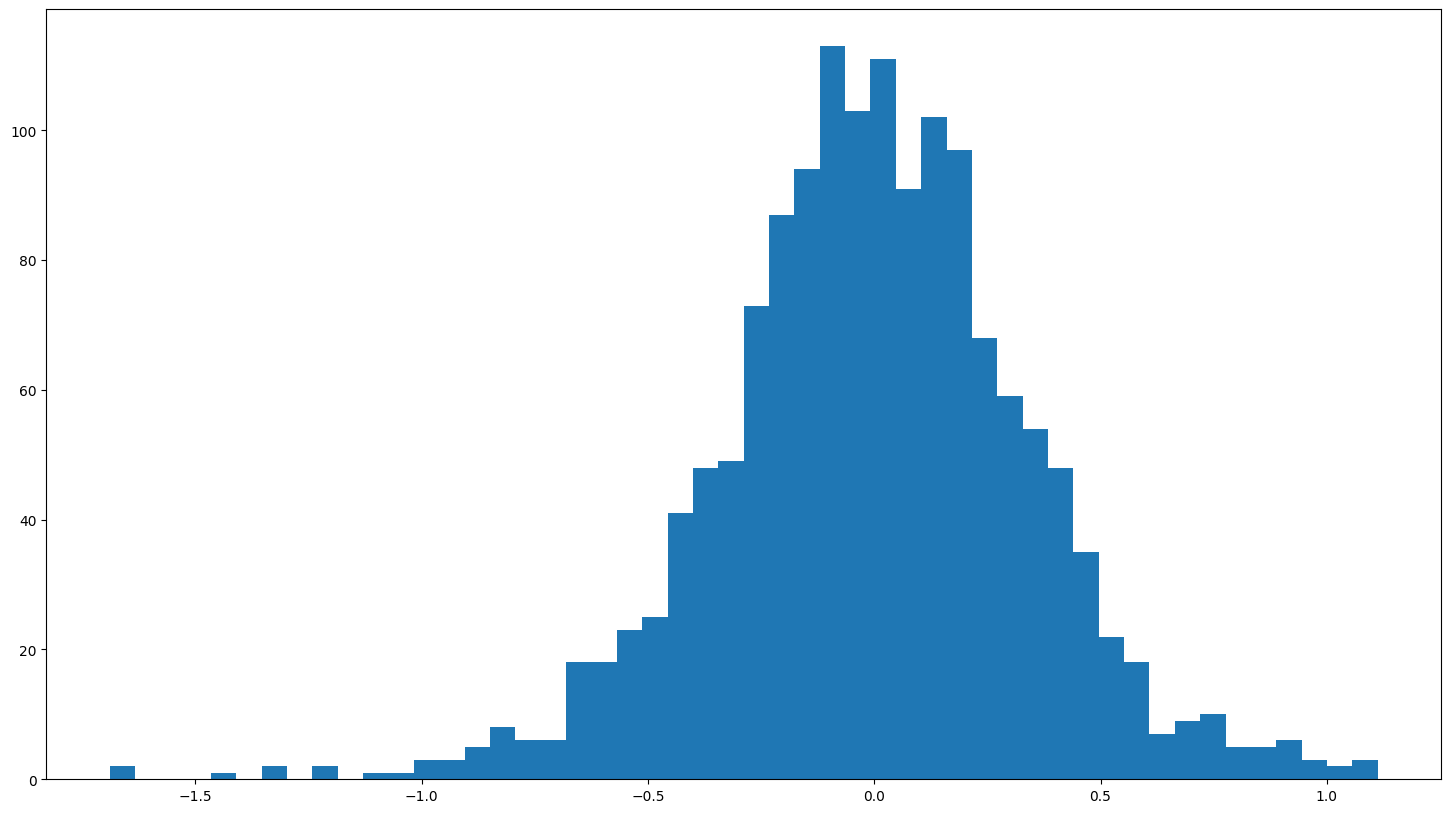

In [31]:
plt.figure(figsize= (18,10))
residuals = stock_data - moving_average_data
plt.hist(residuals, bins=50)
plt.show()

Analizamos el ruido con los valores más altos:

In [32]:
percentile_90 = np.nanpercentile(abs(residuals['Close']),90)
residuals[abs(residuals['Close']) >= percentile_90]

,Close
Date,
2010-03-18,0.5750
2010-03-25,-1.0125
2010-05-05,-0.5700
2010-05-06,-0.6625
2010-05-20,-0.6975
...,...
2015-09-17,0.5875
2015-10-26,-1.2250
2015-10-27,-1.3100


Se calculan los residuos y se representa el resultado en un histograma. Se calculan los residuos hallando la diferencia entre los valores de la media móvil y los de la serie temporal original. A continuación, se representan los residuos en un histograma utilizando el método ```hist``` de ```matplotlib```.   

Este último histograma da una idea de la forma de la distribución de los residuos, en la que los valores situados en los extremos izquierdo y derecho pueden considerarse valores atípicos.    
Se establece un umbral del percentil 90 para revisar los posibles valores atípicos con valores superiores al percentil 90. Estos valores también pueden indicarnos cambios repentinos en la serie temporal.

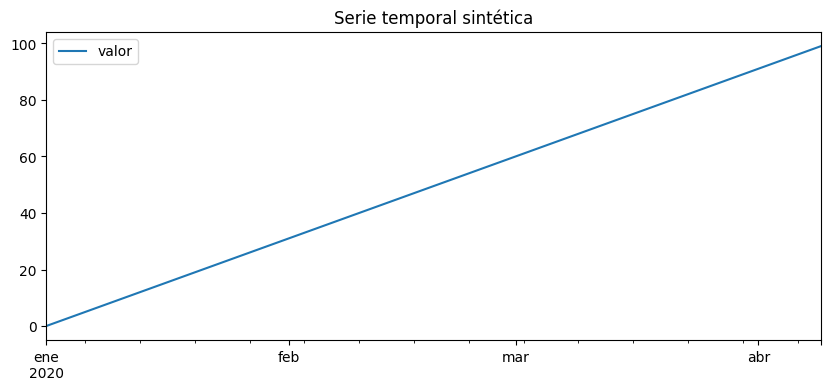

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Creamos una serie temporal sintética
fechas = pd.date_range(start='2020-01-01', periods=100, freq='D')
valores = pd.Series(range(100))
valores.index = fechas
serie = pd.DataFrame({'valor': valores})



serie.plot(figsize=(10,4))
plt.title('Serie temporal sintética')
plt.show()

In [5]:
serie

,valor
2020-01-01,0
2020-01-02,1
2020-01-03,2
2020-01-04,3
2020-01-05,4
...,...
2020-04-05,95
2020-04-06,96
2020-04-07,97
2020-04-08,98


## Descomposición de series temporales
Descomponer una serie temporal consiste en separar sus componentes: tendencia, estacionalidad y residuo. Python permite hacerlo fácilmente con `statsmodels`.

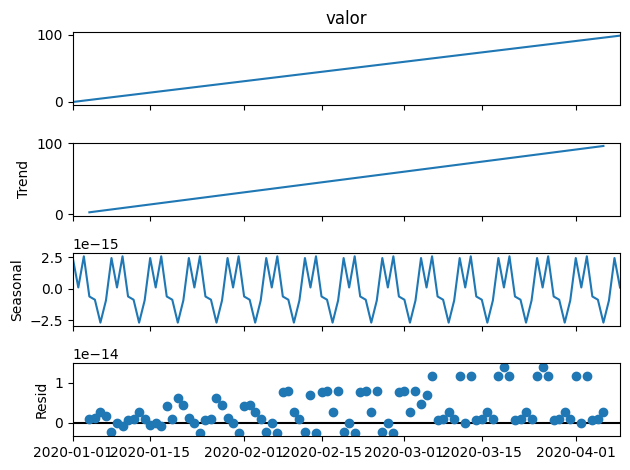

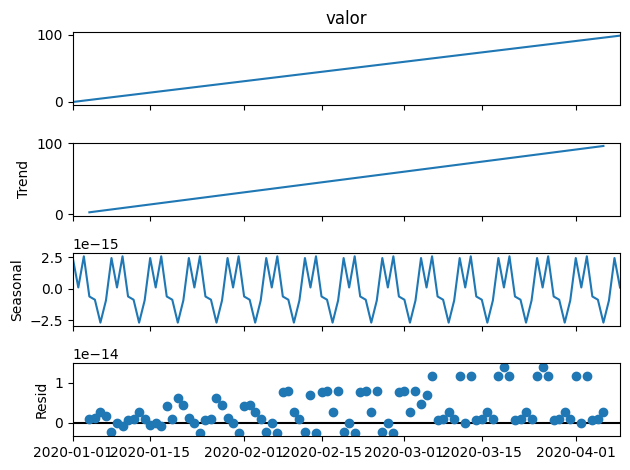

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomp = seasonal_decompose(serie['valor'], model='additive', period=7)
descomp.plot()

## Suavizado y medias móviles
El suavizado permite reducir el ruido y observar mejor la tendencia. La técnica más simple es la **media móvil**.

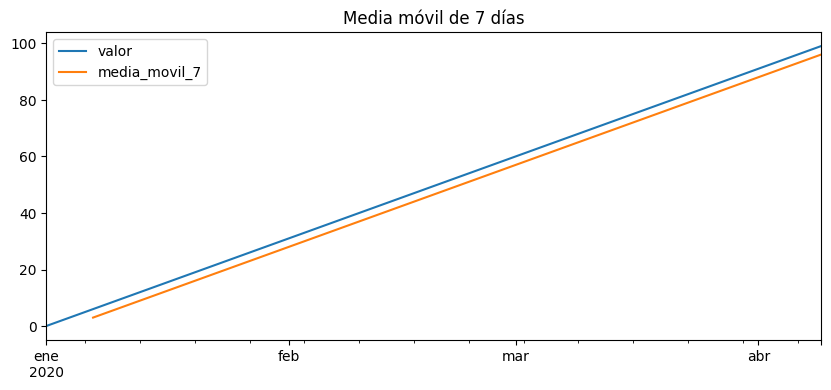

In [7]:
serie['media_movil_7'] = serie['valor'].rolling(window=7).mean()
serie[['valor','media_movil_7']].plot(figsize=(10,4))
plt.title('Media móvil de 7 días')
plt.show()

## Modelos ARIMA
Los modelos ARIMA (Autoregressive Integrated Moving Average) son de los más utilizados para predicciones a corto plazo. Requieren que la serie sea estacionaria.

### Estacionariedad
Una serie es estacionaria si su media y varianza no cambian con el tiempo. Para ello se suele aplicar la **diferenciación**.

<Axes: title={'center': 'Serie diferenciada'}>

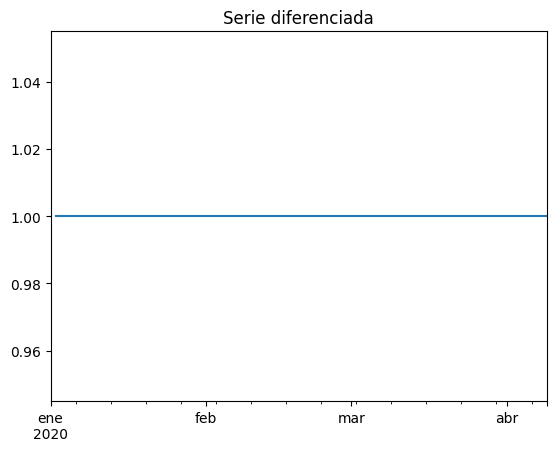

In [8]:
serie['diff'] = serie['valor'].diff()
serie['diff'].plot(title='Serie diferenciada')

### Ajustar un modelo ARIMA
Usaremos `statsmodels` para entrenar un modelo ARIMA simple.

In [9]:
from statsmodels.tsa.arima.model import ARIMA

modelo = ARIMA(serie['valor'], order=(1,1,1))
ajuste = modelo.fit()
print(ajuste.summary())

/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                  valor   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 509.035
Date:                lun, 24 nov 2025   AIC                          -1012.069
Time:                        18:13:44   BIC                          -1004.284
Sample:                    01-01-2020   HQIC                         -1008.919
                         - 04-09-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997   6.81e-05   1.47e+04      0.000       1.000       1.000
ma.L1          0.9988   8.32e-10    1.2e+09      0.000       0.999       0.999
sigma2      1.863e-06   3.71e-07      5.027      0.0

/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Predicción
Una vez entrenado el modelo, podemos generar predicciones.

In [10]:
pred = ajuste.forecast(steps=10)
print(pred)

2020-04-10     99.999830
2020-04-11    100.999319
2020-04-12    101.998469
2020-04-13    102.997278
2020-04-14    103.995748
2020-04-15    104.993878
2020-04-16    105.991669
2020-04-17    106.989120
2020-04-18    107.986232
2020-04-19    108.983005
Freq: D, Name: predicted_mean, dtype: float64
